# Sinkhorn dual potentials as epsilon changes

This notebook generates `fig:sinkhorn-dual-potentials-epsilon`.  For the same one-dimensional Gaussian-mixture histograms, it plots the KL-normalized logarithmic scalings
$$
    f_i^\varepsilon=\varepsilon\log u_i^\varepsilon,
    \qquad
    g_j^\varepsilon=\varepsilon\log v_j^\varepsilon,
$$
with a fixed gauge.  Increasing `epsilon` replaces hard transport geometry by smoother log-sum-exp potentials.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
import ot
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from matplotlib.patches import Polygon

from figure_style import (
    BLUE,
    DIRAC_MARKER_SIZE,
    GRAY,
    LIGHT_GRAY,
    ORANGE,
    RED,
    VIOLET,
    box_axes,
    canonical_matching_clouds,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()
np.random.seed(0)

def normal_pdf(x, mean, std):
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))


def mixture_pdf(x, weights, means, stds):
    density = np.zeros_like(x, dtype=float)
    for weight, mean, std in zip(weights, means, stds):
        density += weight * normal_pdf(x, mean, std)
    return density


def sinkhorn_histograms(n=170):
    grid = np.linspace(-3.25, 3.15, n)
    alpha_density = mixture_pdf(grid, [0.58, 0.42], [-1.95, -0.10], [0.34, 0.54])
    beta_density = mixture_pdf(grid, [0.42, 0.58], [-0.75, 1.55], [0.42, 0.36])
    a = alpha_density / alpha_density.sum()
    b = beta_density / beta_density.sum()
    C = (grid[:, None] - grid[None, :]) ** 2
    C = C / np.median(C[C > 0])
    return grid, alpha_density, beta_density, a, b, C


def kl_normalized_solution(a, b, C, epsilon, *, num_iter=10000):
    K = (a[:, None] * b[None, :]) * np.exp(-C / epsilon)
    plan, log = ot.sinkhorn(
        a,
        b,
        K,
        reg=1.0,
        method="sinkhorn_log",
        log=True,
        numItermax=num_iter,
        stopThr=1e-12,
    )
    f = epsilon * np.asarray(log["log_u"])
    g = epsilon * np.asarray(log["log_v"])
    shift = -float(np.dot(a, f))
    f = f + shift
    g = g - shift
    return plan, f, g

## Shared histograms and gauge

The same density rendering and vertical scale are reused by `fig:sinkhorn-potentials-iterations`.  The gauge is chosen so that `<f,a>=0` in every panel.

In [2]:
fig_name = "sinkhorn-dual-potentials-epsilon"
out = figure_dir(fig_name)

grid, alpha_density, beta_density, a, b, C = sinkhorn_histograms(n=180)
epsilons = [(0.010, "eps-0p010.pdf"), (0.045, "eps-0p045.pdf"), (0.20, "eps-0p200.pdf")]
solutions = []
for epsilon, filename in epsilons:
    plan, f, g = kl_normalized_solution(a, b, C, epsilon)
    solutions.append((epsilon, filename, f, g))

all_values = np.concatenate([np.r_[f, g] for _, _, f, g in solutions])
ymin, ymax = np.percentile(all_values, [1, 99])
pad = 0.16 * (ymax - ymin)
ymin, ymax = ymin - pad, ymax + pad
density_base = ymin + 0.055 * (ymax - ymin)
density_height = 0.145 * (ymax - ymin)

## Exported potential panels

The PDFs contain only curves and density silhouettes.  Parameter values are supplied in LaTeX.

In [3]:
def draw_potential_panel(filename, f, g):
    fig, ax = plt.subplots(figsize=(2.42, 1.88))
    alpha_sil = density_base + density_height * alpha_density / alpha_density.max()
    beta_sil = density_base + density_height * beta_density / beta_density.max()
    ax.fill_between(grid, density_base, alpha_sil, color=RED, alpha=0.15, linewidth=0, zorder=1)
    ax.fill_between(grid, density_base, beta_sil, color=BLUE, alpha=0.15, linewidth=0, zorder=1)
    ax.plot(grid, alpha_sil, color=RED, lw=0.55, alpha=0.75, zorder=2)
    ax.plot(grid, beta_sil, color=BLUE, lw=0.55, alpha=0.75, zorder=2)
    ax.plot(grid, f, color=RED, lw=1.16, zorder=3)
    ax.plot(grid, g, color=BLUE, lw=1.16, zorder=3)
    ax.set_xlim(grid.min(), grid.max())
    ax.set_ylim(ymin, ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    box_axes(ax)
    save_pdf(fig, out / filename, pad_inches=0.055)
    plt.close(fig)


for _, filename, f, g in solutions:
    draw_potential_panel(filename, f, g)

## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


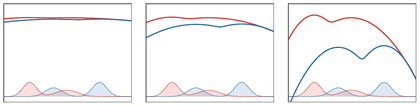

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/sinkhorn-dual-potentials-epsilon.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/sinkhorn-dual-potentials-epsilon.png")
display(Image(filename=str(_thumb)))
